In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'is_gesture'

In [3]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
session_task_min_max_marker AS (
    SELECT
        session_task_id,
        MIN(sensor_data_index) AS min_index,
        MAX(sensor_data_index) AS max_index
    FROM preciseMarker
    GROUP BY session_task_id
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        stmm.min_index,
        stmm.max_index,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 'no' ELSE 'yes' END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    LEFT JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    LEFT JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN session_task_min_max_marker stmm
      ON stmm.session_task_id = sd.session_task_id
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title NOT IN ('Szenarien', 'Tap and Hold') AND sd.session_task_row_index BETWEEN stmm.min_index AND stmm.max_index
)
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [4]:
df_raw.head()

,id,min_index,max_index,session_task_id,session_task_row_index,row_index,timestamp,timestamp_ms,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,group_id
0,c5fc9722-5e29-49b9-935b-bbd1ee137b0e,315,1775,00939e3d-4a5f-4dd7-9bf9-de608222ef04,315,121240,2025-10-03 16:37:57,NaN,0,184.284027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spread Swipe (Links),Spread Swipe,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,yes,2025-10-03 16:37:57
1,acd43510-d840-48f4-9b48-c7f4dc397fbf,315,1775,00939e3d-4a5f-4dd7-9bf9-de608222ef04,316,121241,2025-10-03 16:37:57,NaN,0,184.281723,3.612832,63.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spread Swipe (Links),Spread Swipe,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,yes,2025-10-03 16:37:57
2,c5aec79e-d769-411e-bec4-e2184809be77,315,1775,00939e3d-4a5f-4dd7-9bf9-de608222ef04,317,121242,2025-10-03 16:37:57,NaN,0,184.277496,3.571380,144.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spread Swipe (Links),Spread Swipe,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,yes,2025-10-03 16:37:57
3,06cb8ce8-b503-4922-9f80-ee3b30c92c82,315,1775,00939e3d-4a5f-4dd7-9bf9-de608222ef04,318,121243,2025-10-03 16:37:57,NaN,0,184.275208,3.566890,155.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spread Swipe (Links),Spread Swipe,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,yes,2025-10-03 16:37:57
4,2822738b-a27c-4d33-b771-6d9d4258b64d,315,1775,00939e3d-4a5f-4dd7-9bf9-de608222ef04,319,121244,2025-10-03 16:37:57,NaN,0,184.275208,3.561110,164.0,2.0,4.24115,46.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spread Swipe (Links),Spread Swipe,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,yes,2025-10-03 16:37:57


In [5]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")
df_raw["is_gesture"] = df_raw["is_gesture"].astype("category")

In [6]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [7]:
is_null = df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_raw["group_id"] = df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [8]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'pressure' in col:
#         df_raw[col] = df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 3. Normalize channel values using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'channel' in col:
#         df_raw[col] = df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 4. Normalize motor_angle using min max scaling to [0, 1], per participant
# df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
#     lambda x: (x - x.min()) / (x.max() - x.min())
# )       

In [9]:
df_raw[LABEL_COLUMN].value_counts()

is_gesture
no     205245
yes     40725
Name: count, dtype: int64

In [10]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    30680
6331fbd1-76bb-48d6-92a2-80a55a70d134    27969
696b4743-9d39-4fb1-8271-90e7d48652af    18586
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    37826
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    29543
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    36132
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    32275
fdd02af8-c764-43ba-8247-c612f85568b4    32959
dtype: int64

In [11]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [12]:
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [13]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


In [14]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean.isna().sum()

id                        0
min_index                 0
max_index                 0
session_task_id           0
session_task_row_index    0
row_index                 0
timestamp                 0
timestamp_ms              0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
group_id                  0
estimated_timestamp       0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [15]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Button Press Features
    add_feature("button_pressed_mean", feature_df["button_pressed"].rolling(window=smoothing_window, min_periods=1).mean())
    add_feature("button_pressed_std", feature_df["button_pressed"].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
    add_feature("button_pressed_diff", feature_df["button_pressed"].diff().fillna(0))

    # Motor Angle Features
    add_feature("motor_angle_mean", feature_df["motor_angle"].rolling(window=smoothing_window, min_periods=1).mean())
    add_feature("motor_angle_std", feature_df["motor_angle"].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
    add_feature("motor_angle_diff", feature_df["motor_angle"].diff().fillna(0))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        pres_i = feature_df[f'touch_{i}_pressure']
        pres_j = feature_df[f'touch_{j}_pressure']

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        add_feature(dist_col, dist)
        add_feature(f"{dist_col}_mean", dist.rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f"{dist_col}_std", dist.rolling(window=smoothing_window, min_periods=1).std().fillna(0))

        both_active = (pres_i > 0) & (pres_j > 0)
        add_feature(f"{dist_col}_both_active", dist.where(both_active).fillna(0))
        add_feature(f"{dist_col}_both_active_mean", dist.where(both_active).rolling(window=smoothing_window, min_periods=1).mean().fillna(0))


    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

        pressure_rising_edge = (feature_df[pressure_col].diff() > 0) & (feature_df[pressure_col] > 0)
        add_feature(f'{pressure_col}_rising_edge', pressure_rising_edge.astype(int))

    return feature_df, additional_features

In [16]:
def get_column_names(feature_columns):
    # return feature_columns
    # return SENSOR_COLUMNS
    return SENSOR_COLUMNS + feature_columns

In [17]:
# get the max sample size, grouped by group_id where is_gesture == 'yes'
max_gesture_size = df_clean[df_clean[LABEL_COLUMN] == 'yes'].groupby('group_id').size().max()
max_gesture_size

np.int64(215)

In [18]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = get_column_names(additional_columns)

In [19]:
df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    # - or group_id changes
    # - or the gesture_block is currently longer than max_gesture_size
    current_block_size = blocks.count(gesture_block)
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        group_id != prev_group_id or
        current_block_size >= max_gesture_size
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_group_id = group_id

df["gesture_block"] = blocks

In [20]:
# Check how many gesture_blocks there are with 10 or less samples
block_sizes = df.groupby("gesture_block").size()
small_blocks = block_sizes[block_sizes <= 10]
print(f"Number of gesture blocks with 10 or less samples: {len(small_blocks)}")

# Remove them
df = df[~df["gesture_block"].isin(small_blocks.index)].reset_index(drop=True)

Number of gesture blocks with 10 or less samples: 220


In [21]:
# Print the amount of unique gesture blocks
print("Unique gesture blocks:", df["gesture_block"].nunique())
# Print the min, max and average block length
block_lengths = df.groupby("gesture_block").size()
print("Block length stats - min:", block_lengths.min(), "max:", block_lengths.max(), "mean:", block_lengths.mean())

Unique gesture blocks: 2386
Block length stats - min: 11 max: 215 mean: 102.82187761944677


In [22]:
gesture_blocks = (
    df
    .groupby(["participant_id", "session_task_id", "gesture_block", "group_id"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 2386


In [23]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, gb, group_id), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "group_id": group_id,
        "num_samples": len(X_seq),
    })

In [24]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 2386 sequences with 2 unique labels.
Label counts:
  no: 1507
  yes: 879


In [25]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

print(max_len)

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded


215


In [27]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

np.random.seed(42)
val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 8
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [28]:
# Split participants into train, val, test sets
train_indices = df['participant_id'].isin(train_participants)
val_indices = df['participant_id'].isin(val_participants)
test_indices = df['participant_id'].isin(test_participants)

# Map each sequence back to its participant_id
sequence_participants = []
gesture_block_keys = list(gesture_blocks.groups.keys())
for (pid, sid, gb, group_id) in gesture_block_keys:
    sequence_participants.append(pid)
sequence_participants = np.array(sequence_participants)
# Now create boolean masks for sequences
train_seq_indices = np.isin(sequence_participants, train_participants)
val_seq_indices = np.isin(sequence_participants, val_participants)
test_seq_indices = np.isin(sequence_participants, test_participants)

X_train, y_train = X[train_seq_indices], y[train_seq_indices]
X_val, y_val = X[val_seq_indices], y[val_seq_indices]
X_test, y_test = X[test_seq_indices], y[test_seq_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (1801, 215, 109), (1801, 2)
Validation set: (286, 215, 109), (286, 2)
Test set: (299, 215, 109), (299, 2)


In [29]:
# Per label, print the amount of samples in each split in one row
labels_list = le.classes_.tolist()
print(f"{'Label':<15} {'Train':<10} {'Validation':<10} {'Test':<10}")
for label in labels_list:
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)
    test_count = np.sum(y_test == label)
    print(f"{label:<15} {train_count:<10} {val_count:<10} {test_count:<10}")

Label           Train      Validation Test      
no              0          0          0         
yes             0          0          0         


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation="softmax"))
optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 215, 109)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 215, 128)       │       121,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,554 (685.76 KB)

 Trainable params: 175,554 (685.76 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8240 - loss: 0.3960 - val_accuracy: 0.8881 - val_loss: 0.2589
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9345 - loss: 0.1621 - val_accuracy: 0.9126 - val_loss: 0.2175
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9550 - loss: 0.1191 - val_accuracy: 0.9266 - val_loss: 0.2047
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9589 - loss: 0.1128 - val_accuracy: 0.9266 - val_loss: 0.1656
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9767 - loss: 0.0683 - val_accuracy: 0.9336 - val_loss: 0.2171
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9817 - loss: 0.0503 - val_accuracy: 0.9161 - val_loss: 0.2450
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9861 - loss: 0.0372 - val_accuracy: 0.9161 - val_loss: 0.2533
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9783 - loss: 0.0514 - 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       185
           1       0.91      1.00      0.95       114

    accuracy                           0.96       299
   macro avg       0.96      0.97      0.96       299
weighted avg       0.97      0.96      0.96       299



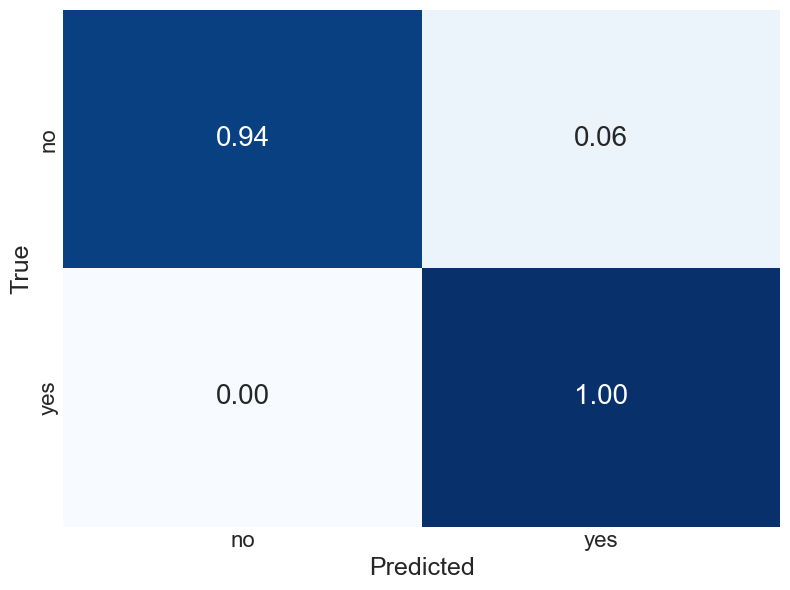

In [32]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

used_labels = np.unique(np.concatenate([y_test_pred, y_test_true]))
used_labels_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_test_true,
        y_test_pred,
    )
)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues", 
            annot_kws={"fontsize": 20},
            cbar=False)
plt.xlabel("Predicted", fontsize=18)
plt.ylabel("True", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


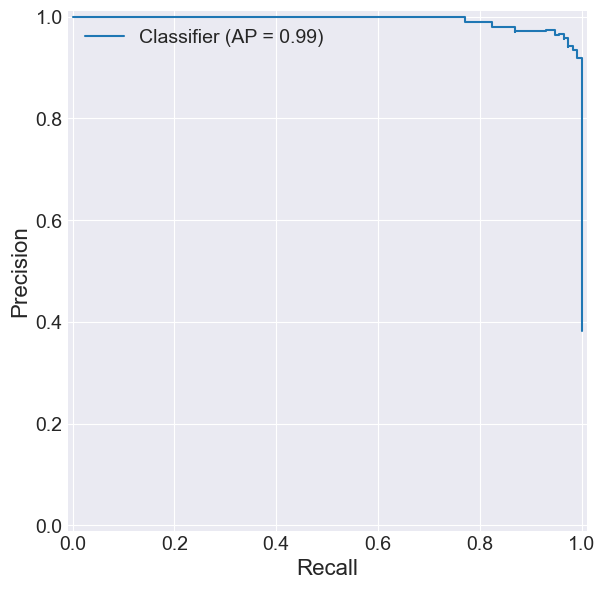

In [57]:
# draw a precision recall curve for the best model
from sklearn.metrics import PrecisionRecallDisplay
y_test_pred_probs = model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
disp = PrecisionRecallDisplay.from_predictions(
    y_test_true,
    y_test_pred_probs[:, 1],
    ax=ax
)

disp.ax_.set_xlabel("Recall", fontsize=16)                  # x-axis
disp.ax_.set_ylabel("Precision", fontsize=16)              # y-axis
disp.ax_.tick_params(axis='both', labelsize=12)            # tick labels
disp .ax_.legend(fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


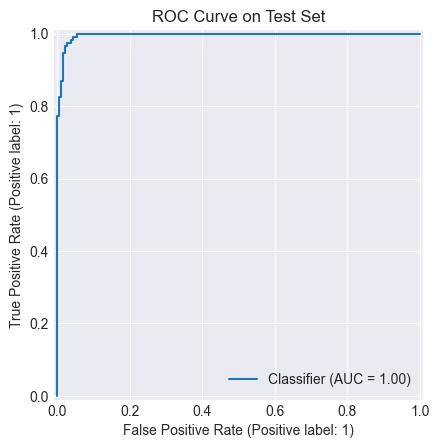

In [34]:
# draw a receiver operating characteristic (ROC) curve for the best model
from sklearn.metrics import RocCurveDisplay
y_test_pred_probs = model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)
roc_display = RocCurveDisplay.from_predictions(
    y_test_true,
    y_test_pred_probs[:, 1],
)
plt.title("ROC Curve on Test Set")
plt.show()

## Test with Szenario

In [35]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    rt.title AS gesture,
    rtParent.title AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 'no' ELSE 'yes' END AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None


In [36]:
# Print counts of unique gestures per participant_id
counts = (
    szenarien_df_raw
    .groupby(['participant_id', 'gesture'])
    .size()
    .reset_index(name='count')
)

print(counts)

                          participant_id           gesture  count
0   6331fbd1-76bb-48d6-92a2-80a55a70d134   Bild vergrößern   1389
1   6331fbd1-76bb-48d6-92a2-80a55a70d134  Dateien kopieren   2099
2   6331fbd1-76bb-48d6-92a2-80a55a70d134    Musik Vorschau   1374
3   696b4743-9d39-4fb1-8271-90e7d48652af   Bild vergrößern   1013
4   696b4743-9d39-4fb1-8271-90e7d48652af  Dateien kopieren   1029
5   696b4743-9d39-4fb1-8271-90e7d48652af    Musik Vorschau    928
6   6a1b56e6-47ce-43cb-96cb-713d055d8f6d   Bild vergrößern   2817
7   6a1b56e6-47ce-43cb-96cb-713d055d8f6d  Dateien kopieren   2009
8   6a1b56e6-47ce-43cb-96cb-713d055d8f6d    Musik Vorschau   2355
9   707c3867-fe15-4b05-bf7b-fc5f3b501fb1   Bild vergrößern   1425
10  707c3867-fe15-4b05-bf7b-fc5f3b501fb1    Musik Vorschau   1195
11  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0   Bild vergrößern    913
12  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0  Dateien kopieren   1204
13  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    Musik Vorschau   2362
14  d3b39f

In [37]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [38]:
is_null = szenarien_df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
szenarien_df_raw["group_id"] = szenarien_df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [39]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df_raw[col] = szenarien_df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'pressure' in col:
#         szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 3. Normalize channel values using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'channel' in col:
#         szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 4. Normalize motor_angle using min max scaling to [0, 1], per participant
# szenarien_df_raw['motor_angle'] = szenarien_df_raw.groupby('participant_id')['motor_angle'].transform(
#     lambda x: (x - x.min()) / (x.max() - x.min())
# )       

In [40]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [41]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df.isna().sum()

id                        0
session_task_id           0
session_task_row_index    0
timestamp                 0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
marker_label              0
group_id                  0
estimated_timestamp       0
timestamp_ms              0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [42]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
no     27560
yes     6248
Name: count, dtype: int64


In [43]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [44]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)
streams_meta = {}

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    meta_stream = {
        "participant_id": sdf["participant_id"].iloc[0],
        "session_task_id": sid,
        "num_samples": len(sdf),
    }
    streams[sid] = X_stream
    streams_labels[sid] = y_stream
    streams_meta[sid] = meta_stream

In [45]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 20 streams from Szenarien data.


In [46]:
max_len = max_len
step_size = 10

print(f"Using max_len={max_len} for online prediction.")
def predict_stream_online(X_stream, y_stream):
    T, D = X_stream.shape
    preds = []
    probas = []
    real_labels = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        window = X_stream[t_start:t_end]
        window_labels = y_stream[t_start:t_end]

        real_label = 'no'
        if 'yes' in window_labels and window_labels[0] == 'no' and window_labels[-1] == 'no':
            real_label = 'yes'
        real_labels.append(real_label)

        # Predict the probabilities for the window
        window_padded = pad_sequences(
            [window],
            maxlen=max_len,
            dtype="float32",
            padding="pre",
            truncating="pre",
            value=0.0
        )
        proba = model.predict(window_padded, verbose=0)[0]
        probas.append(proba)

        cls_idx = np.argmax(proba)
        label = le.classes_[cls_idx]
        preds.append(label)

    return np.array(preds), np.array(real_labels), np.array(probas), windows


Using max_len=215 for online prediction.


In [47]:
all_true = []
all_prediced = []
all_probabilities = []

total_streams = len(streams)
current_stream = 1
for sid, X_stream in streams.items():
    print(f"Predicting stream {current_stream}/{total_streams} (session_task_id={sid})...")
    current_stream += 1
    y_stream = streams_labels[sid]
    preds, real_labels, probas, windows = predict_stream_online(X_stream, y_stream)
    
    all_true.extend(real_labels)
    all_prediced.extend(preds)
    all_probabilities.extend(probas)

Predicting stream 1/20 (session_task_id=002f4422-1f7b-4859-8f03-467e1f752000)...
Predicting stream 2/20 (session_task_id=0542a515-ad14-49ec-84d7-c3b4e8b6ffe2)...
Predicting stream 3/20 (session_task_id=1428d33a-3bff-4f49-ba25-dca7d3980421)...
Predicting stream 4/20 (session_task_id=19bae408-9256-4cb3-930b-4beaa4875157)...
Predicting stream 5/20 (session_task_id=2789503c-76bf-4451-9bf7-9b7417c8b08e)...
Predicting stream 6/20 (session_task_id=319a52f3-2f36-4460-ba9d-a4346666683f)...
Predicting stream 7/20 (session_task_id=37f425a5-7c3c-4444-9bca-26e3fd5f0186)...
Predicting stream 8/20 (session_task_id=3be34428-0cf8-44c9-8b61-8172643e235d)...
Predicting stream 9/20 (session_task_id=4828a4ce-5192-4853-906e-1d79fd94da44)...
Predicting stream 10/20 (session_task_id=5658dcb6-a957-4027-a893-3b335e8ca212)...
Predicting stream 11/20 (session_task_id=5c21a030-cd27-4e99-b8c0-18f30cfa3fc3)...
Predicting stream 12/20 (session_task_id=6372259a-787d-4b7c-84b7-2eca71318068)...
Predicting stream 13/20 (

In [48]:
all_true_arr = np.array(all_true)
all_prediced_arr = np.array(all_prediced)
all_probabilities_arr = np.array(all_probabilities)

print(f"Unique true labels: {np.unique(all_true_arr)}")
print(f"Unique predicted labels: {np.unique(all_prediced_arr)}")

Unique true labels: ['no' 'yes']
Unique predicted labels: ['no' 'yes']


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

all_true_int = le.transform(all_true_arr)
all_prediced_int = le.transform(all_prediced_arr)

used_labels = np.unique(np.concatenate([all_true_int, all_prediced_int]))
used_labels_names = le.inverse_transform(used_labels)
print(
    classification_report(
        all_true_int,
        all_prediced_int,
        labels=used_labels,
        target_names=used_labels_names
    )
)

              precision    recall  f1-score   support

          no       0.60      0.94      0.73      1759
         yes       0.43      0.07      0.12      1203

    accuracy                           0.59      2962
   macro avg       0.51      0.50      0.42      2962
weighted avg       0.53      0.59      0.48      2962



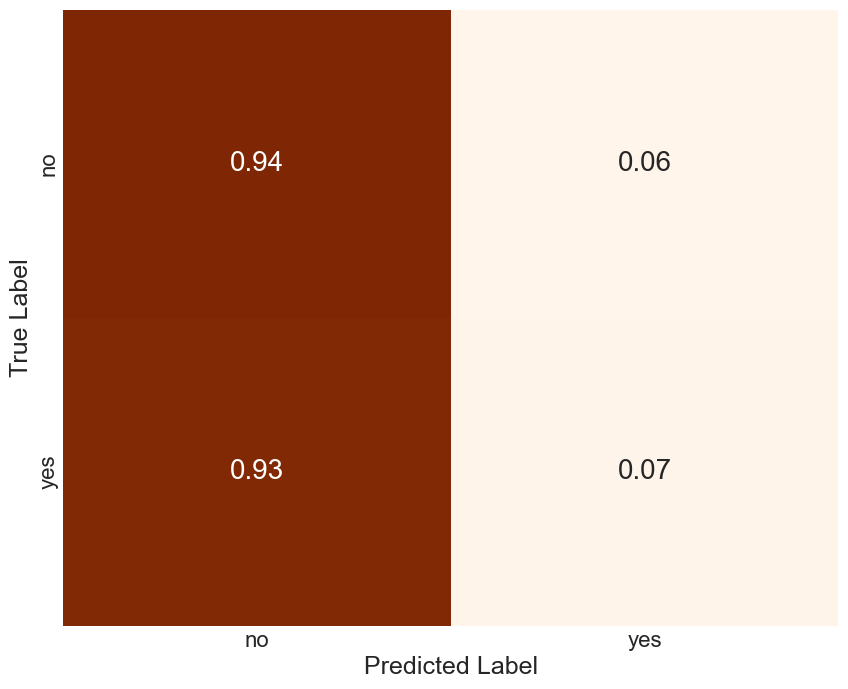

In [50]:
cm = confusion_matrix(all_true_int, all_prediced_int, labels=used_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap="Oranges",
    xticklabels=used_labels_names,
    yticklabels=used_labels_names,
    annot_kws={"fontsize": 20},
    cbar=False
)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.show()

## Szenario Full Windows

In [51]:
# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 319 windows from Szenarien data for group_id prediction.


In [52]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=4, max=940
Window label counts:
  no: 187
  yes: 132


In [53]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = pad_sequences(
        [X_window],
        maxlen=max_len,
        dtype="float32",
        padding="pre",
        truncating="pre",
        value=0.0
    )
    proba = model.predict(X_batch, verbose=0)[0]
    
    all_window_proba.append(proba)
    all_window_true.append(true_label)

    final_prediction = np.argmax(proba)
    pred_label = le.classes_[final_prediction]
    all_window_pred.append(pred_label)

# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (2) ['no' 'yes']
Unique predicted window labels: (2) ['no' 'yes']


              precision    recall  f1-score   support

          no       0.68      0.96      0.79       187
         yes       0.87      0.35      0.50       132

    accuracy                           0.71       319
   macro avg       0.77      0.66      0.65       319
weighted avg       0.76      0.71      0.67       319



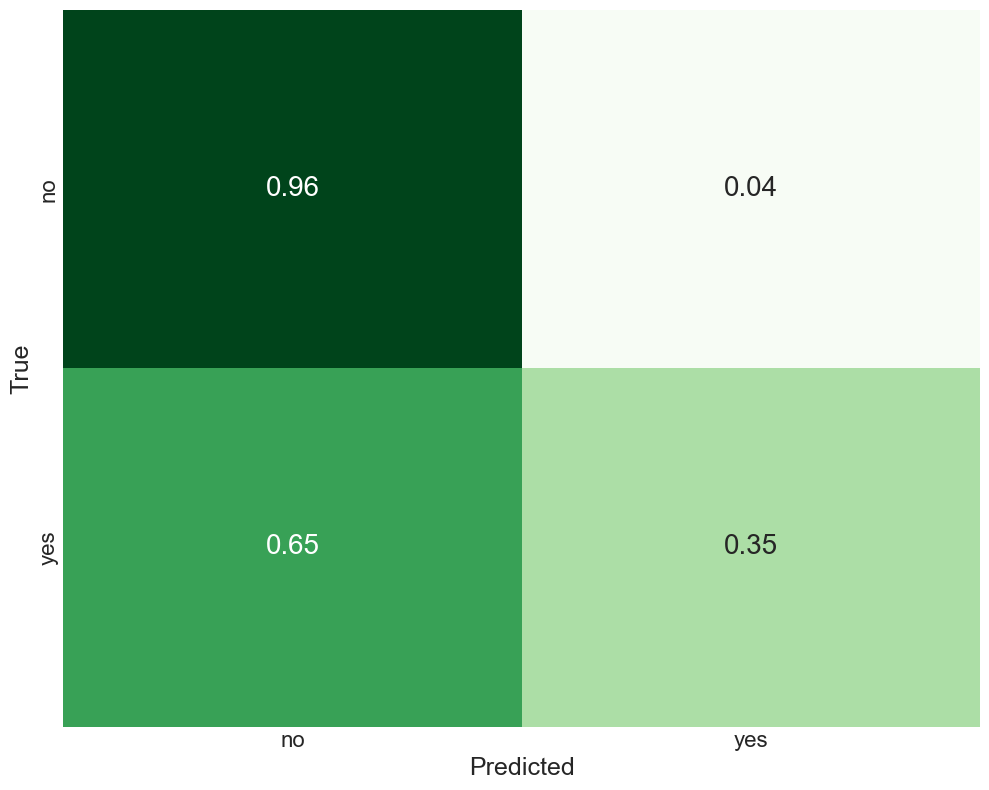

In [54]:
# Print confusion matrix and classification report for window predictions
used_labels_window = np.unique(np.concatenate([all_window_true, all_window_pred]))
print(
    classification_report(
        all_window_true,
        all_window_pred,
        labels=used_labels_window,
    )
)

cm_window = confusion_matrix(all_window_true, all_window_pred)
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=used_labels_window,
    yticklabels=used_labels_window,
    annot_kws={"fontsize": 20},
    cbar=False
)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Predicted", fontsize=18)
plt.ylabel("True", fontsize=18)
plt.tight_layout()
plt.show()

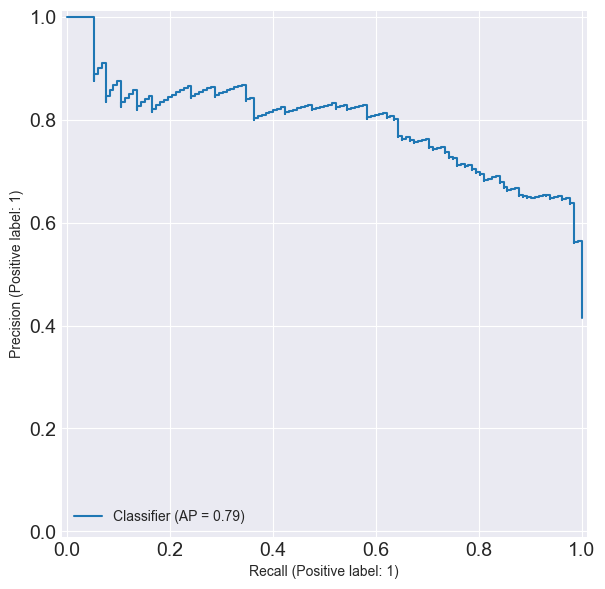

In [58]:
# draw a precision recall curve for the best model
all_window_true_int = le.transform(all_window_true)
fig, ax = plt.subplots(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(
    all_window_true_int,
    all_window_proba[:, 1],
    ax=ax
)

disp.ax_.set_xlabel("Recall", fontsize=16)                  # x-axis
disp.ax_.set_ylabel("Precision", fontsize=16)              # y-axis
disp.ax_.tick_params(axis='both', labelsize=12)            # tick labels
disp .ax_.legend(fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


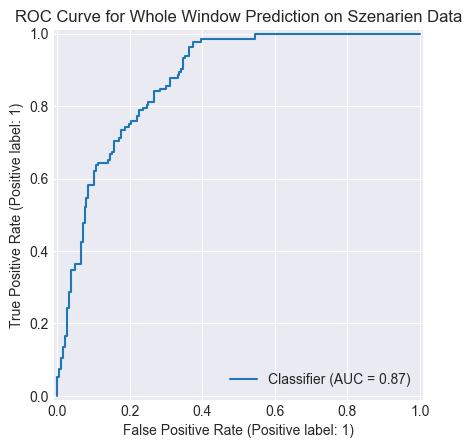

In [56]:
# draw a receiver operating characteristic (ROC) curve for the best model
RocCurveDisplay.from_predictions(
    all_window_true_int,
    all_window_proba[:, 1],
)
plt.title("ROC Curve for Whole Window Prediction on Szenarien Data")
plt.show()